In [39]:
import pandas as pd
import os
import cv2
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [40]:
df = pd.read_csv("Dataset/wdbc.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [41]:
df.shape

(569, 32)

In [42]:
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
      dtype='int64')

In [43]:
df.info

<bound method DataFrame.info of            0  1      2      3       4       5        6        7        8   \
0      842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.30010   
1      842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.08690   
2    84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.19740   
3    84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.24140   
4    84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.19800   
..        ... ..    ...    ...     ...     ...      ...      ...      ...   
564    926424  M  21.56  22.39  142.00  1479.0  0.11100  0.11590  0.24390   
565    926682  M  20.13  28.25  131.20  1261.0  0.09780  0.10340  0.14400   
566    926954  M  16.60  28.08  108.30   858.1  0.08455  0.10230  0.09251   
567    927241  M  20.60  29.33  140.10  1265.0  0.11780  0.27700  0.35140   
568     92751  B   7.76  24.54   47.92   181.0  0.05263  0.04362  0.00000   

          9   ...      22     23      24   

In [44]:
columns = ["ID", "Diagnosis"] + [f"Feature_{i}" for i in range(1,31)]
df.columns = columns

df.head()

,ID,Diagnosis,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,...,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [45]:
col_names = ["ID","Diagnosis"]

for col in col_names:
    
    print(df[col].value_counts())   

ID
842302      1
842517      1
84300903    1
84348301    1
84358402    1
           ..
926424      1
926682      1
926954      1
927241      1
92751       1
Name: count, Length: 569, dtype: int64
Diagnosis
B    357
M    212
Name: count, dtype: int64


In [46]:
df.isnull().sum()

ID            0
Diagnosis     0
Feature_1     0
Feature_2     0
Feature_3     0
Feature_4     0
Feature_5     0
Feature_6     0
Feature_7     0
Feature_8     0
Feature_9     0
Feature_10    0
Feature_11    0
Feature_12    0
Feature_13    0
Feature_14    0
Feature_15    0
Feature_16    0
Feature_17    0
Feature_18    0
Feature_19    0
Feature_20    0
Feature_21    0
Feature_22    0
Feature_23    0
Feature_24    0
Feature_25    0
Feature_26    0
Feature_27    0
Feature_28    0
Feature_29    0
Feature_30    0
dtype: int64

In [47]:
df = df.drop("ID", axis=1)

In [48]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [49]:
df["Diagnosis"] = df["Diagnosis"].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Diagnosis   569 non-null    category
 1   Feature_1   569 non-null    float64 
 2   Feature_2   569 non-null    float64 
 3   Feature_3   569 non-null    float64 
 4   Feature_4   569 non-null    float64 
 5   Feature_5   569 non-null    float64 
 6   Feature_6   569 non-null    float64 
 7   Feature_7   569 non-null    float64 
 8   Feature_8   569 non-null    float64 
 9   Feature_9   569 non-null    float64 
 10  Feature_10  569 non-null    float64 
 11  Feature_11  569 non-null    float64 
 12  Feature_12  569 non-null    float64 
 13  Feature_13  569 non-null    float64 
 14  Feature_14  569 non-null    float64 
 15  Feature_15  569 non-null    float64 
 16  Feature_16  569 non-null    float64 
 17  Feature_17  569 non-null    float64 
 18  Feature_18  569 non-null    float64 
 19  Feature_

In [50]:
df["Diagnosis"] = df["Diagnosis"].str.strip()
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

In [51]:
import matplotlib.pyplot as plt

# Count class distribution
class_counts = df["Diagnosis"].value_counts()

print(class_counts)

Diagnosis
0    357
1    212
Name: count, dtype: int64


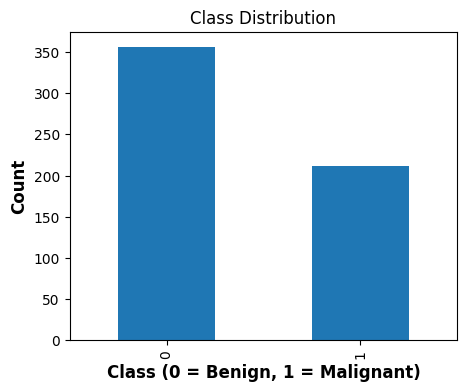

In [52]:
plt.figure(figsize=(5,4))
class_counts.plot(kind='bar')
plt.xlabel("Class (0 = Benign, 1 = Malignant)", fontweight="bold", fontsize=12)
plt.ylabel("Count", fontweight="bold", fontsize=12)
plt.title("Class Distribution")
plt.show()

In [53]:
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.shape, X_test.shape

((455, 30), (114, 30))

In [55]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Base estimator
dt = DecisionTreeClassifier(random_state=42)

# Bagging model
bag_model = BaggingClassifier(
    estimator=dt,
    n_estimators=10,
    random_state=42
)

# Train
bag_model.fit(X_train, y_train)

# Predict
y_pred_bag = bag_model.predict(X_test)

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

acc_bag = accuracy_score(y_test, y_pred_bag)
prec_bag = precision_score(y_test, y_pred_bag)
rec_bag = recall_score(y_test, y_pred_bag)
f1_bag = f1_score(y_test, y_pred_bag)

print("Bagging Model Performance")
print("Accuracy:", acc_bag)
print("Precision:", prec_bag)
print("Recall:", rec_bag)
print("F1 Score:", f1_bag)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bag))

Bagging Model Performance
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1 Score: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [57]:
cm = confusion_matrix(y_test, y_pred_bag)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[72  0]
 [ 4 38]]


In [58]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)

In [59]:
# Accuracy
acc_ada = accuracy_score(y_test, y_pred_ada)
prec_ada = precision_score(y_test, y_pred_ada)
rec_ada = recall_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)

print("AdaBoost Model Performance")
print("Accuracy:", acc_ada)
print("Precision:", prec_ada)
print("Recall:", rec_ada)
print("F1 Score:", f1_ada)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Model Performance
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9523809523809523
F1 Score: 0.975609756097561

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [60]:
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("Confusion Matrix:\n", cm_ada)

Confusion Matrix:
 [[72  0]
 [ 2 40]]


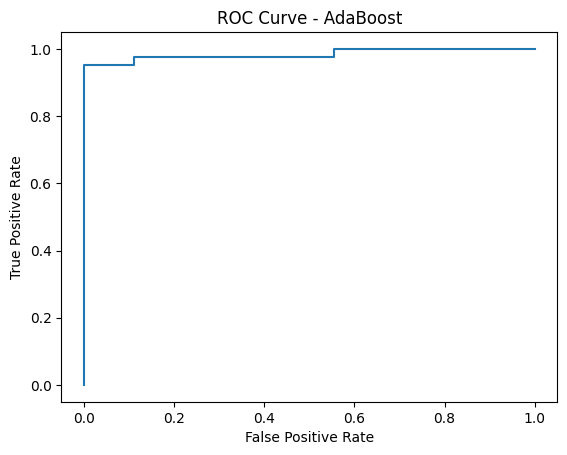

AUC Score: 0.9841269841269842


In [61]:
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_test, y_prob_ada)
auc_ada = roc_auc_score(y_test, y_prob_ada)

plt.figure()
plt.plot(fpr_ada, tpr_ada)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.show()

print("AUC Score:", auc_ada)

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

In [63]:
# Accuracy
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print("Accuracy:", acc_gb)
print("Precision:", prec_gb)
print("Recall:", rec_gb)
print("F1 Score:", f1_gb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Performance
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
F1 Score: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [64]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
print("Confusion Matrix:\n", cm_gb)

Confusion Matrix:
 [[72  0]
 [ 4 38]]


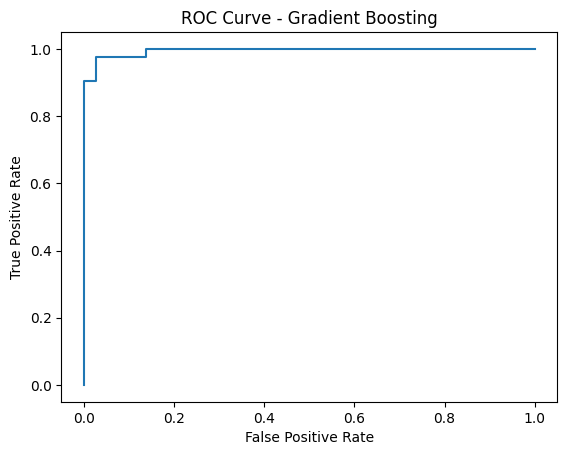

AUC Score: 0.9947089947089948


In [65]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.figure()
plt.plot(fpr_gb, tpr_gb)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.show()

print("AUC Score:", auc_gb)

In [66]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Define base models
base_models = [
    ('svm', SVC(probability=True, random_state=42)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

# Define meta learner
meta_model = LogisticRegression()

# Create stacking model
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

# Train
stack_model.fit(X_train, y_train)

# Predict
y_pred_stack = stack_model.predict(X_test)

In [67]:
# Accuracy
acc_stack = accuracy_score(y_test, y_pred_stack)
prec_stack = precision_score(y_test, y_pred_stack)
rec_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)

print("Stacked Ensemble Performance")
print("Accuracy:", acc_stack)
print("Precision:", prec_stack)
print("Recall:", rec_stack)
print("F1 Score:", f1_stack)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_stack))

Stacked Ensemble Performance
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1 Score: 0.9629629629629629

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [68]:
cm_stack = confusion_matrix(y_test, y_pred_stack)
print("Confusion Matrix:\n", cm_stack)

Confusion Matrix:
 [[72  0]
 [ 3 39]]


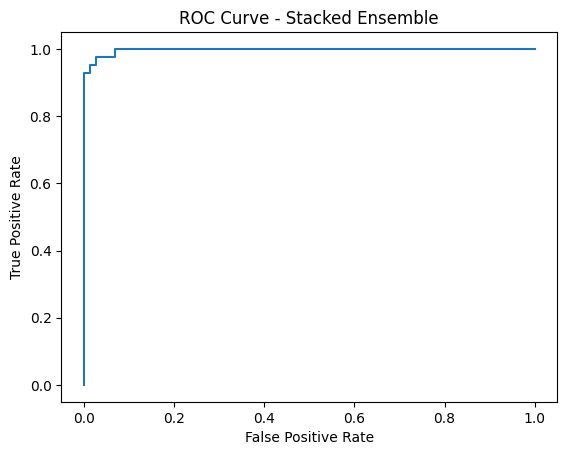

AUC Score: 0.9973544973544974


In [69]:
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]

fpr_stack, tpr_stack, thresholds_stack = roc_curve(y_test, y_prob_stack)
auc_stack = roc_auc_score(y_test, y_prob_stack)

plt.figure()
plt.plot(fpr_stack, tpr_stack)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacked Ensemble")
plt.show()

print("AUC Score:", auc_stack)

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid_bag = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0]
}

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

grid_bag = GridSearchCV(
    estimator=bag,
    param_grid=param_grid_bag,
    cv=5,
    scoring='f1',
    n_jobs=1
)

grid_bag.fit(X_train, y_train)

print("Best Parameters (Bagging):", grid_bag.best_params_)
print("Best CV F1 Score:", grid_bag.best_score_)

Best Parameters (Bagging): {'max_samples': 1.0, 'n_estimators': 100}
Best CV F1 Score: 0.9457358553934497


In [71]:
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

ada = AdaBoostClassifier(random_state=42)

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=5,
    scoring='f1',
    n_jobs=1
)

grid_ada.fit(X_train, y_train)

print("Best Parameters (AdaBoost):", grid_ada.best_params_)
print("Best CV F1 Score:", grid_ada.best_score_)

Best Parameters (AdaBoost): {'learning_rate': 1.0, 'n_estimators': 200}
Best CV F1 Score: 0.9524117381009392


In [72]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 4]
}

gb = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=1
)

grid_gb.fit(X_train, y_train)

print("Best Parameters (Gradient Boosting):", grid_gb.best_params_)
print("Best CV F1 Score:", grid_gb.best_score_)

Best Parameters (Gradient Boosting): {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9477120659977528


In [73]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Bagging", "AdaBoost", "Gradient Boosting", "Stacked Ensemble"],
    "Accuracy": [acc_bag, acc_ada, acc_gb, acc_stack],
    "Precision": [prec_bag, prec_ada, prec_gb, prec_stack],
    "Recall": [rec_bag, rec_ada, rec_gb, rec_stack],
    "F1 Score": [f1_bag, f1_ada, f1_gb, f1_stack]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.964912,1.0,0.904762,0.950000
1,AdaBoost,0.982456,1.0,0.952381,0.975610
2,Gradient Boosting,0.964912,1.0,0.904762,0.950000
3,Stacked Ensemble,0.973684,1.0,0.928571,0.962963
